# Task 7: Physics-Guided Machine Learning (PINN)

### Objective
Design and train a Physics-Informed Neural Network (PINN) to classify strong gravitational lensing images into three distinct categories: **No Substructure**, **Subhalo**, and **Vortex**. The primary goal is to integrate the gravitational lensing equation directly into the network architecture to surpass the performance of a purely data-driven baseline (Task 1).

### The Approach: Why a PINN?
Standard image classifiers treat input data merely as grids of pixel intensities, completely blind to the natural laws that generated those images. While they can find statistical correlations, they are prone to overfitting and domain shifts.

In this approach, we bridge the gap between deep learning and astrophysics by introducing **Physics-Informed Constraints**. 
* **The Mechanism:** We incorporate elements of the gravitational lensing equation into the network's learning process. 
* **The Benefit:** Instead of relying solely on Cross-Entropy loss, the physics constraint acts as a powerful, domain-specific regularizer. It explicitly penalizes the network for extracting feature representations that violate the underlying physics of light deflection. This forces the model into a more robust mathematical minimum, resulting in a tighter class separation and a higher **ROC-AUC** score (0.958) than the baseline.

### Notebook Execution Flow
This notebook is fully reproducible and utilizes our custom modular pipeline:
1. **Configuration & Factory:** Dynamically loading the PINN architecture and dataset parameters via Hydra.
2. **Data Pipeline:** Loading the 3-class dataset (originally min-max normalized) and applying optimal transformations.
3. **Training the PINN:** Running the custom Trainer that simultaneously optimizes for classification accuracy and physical consistency.
4. **Evaluation:** Plotting the **ROC Curve** and calculating the final **AUC Score** on the unseen validation split.

In [1]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("..")
sys.path.append(os.getcwd())
    
print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion\Task_7_Physics_Guided_ML
New CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion


In [2]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

d:\Shreyas\ML4Sci-Deeplense-Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.10.0+cu126
CUDA Available: True


In [3]:
import tempfile
from IPython.display import Markdown

BEST_RUN_ID = "49a4f8f8f17842a28f223451adc518a4"

# CONFIGURATION
CONFIG_ARTIFACT_PATH = "config/config.yaml"

client = mlflow.tracking.MlflowClient()

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        # Download the config file directly from MLflow's artifact store
        local_config_path = client.download_artifacts(
            BEST_RUN_ID, CONFIG_ARTIFACT_PATH, tmp_dir
        )

        # Read the YAML text
        with open(local_config_path, "r") as f:
            config_text = f.read()

        # Render it with syntax highlighting
        display(
            Markdown(
                f"### Experiment Configuration (Run ID: `{BEST_RUN_ID}`)\n"
                f"```yaml\n{config_text}\n```"
            )
        )

    except Exception as e:
        print(f"Could not load the configuration artifact. Error: {e}")

### Experiment Configuration (Run ID: `49a4f8f8f17842a28f223451adc518a4`)
```yaml
dataset:
  name: deeplense_classify
  image_size: 150
  batch_size: 64
  data_root: datasets/deeplense_classify/dataset
model:
  name: pinn_efficient_net_b2
  type: classifier
  backbone:
    pretrained: true
    num_classes: 3
    in_channels: 2
  physics_module:
    in_channels: 1
    estimator_channels:
    - 8
    - 16
  metrics:
    acc:
      name: accuracy
    roc_auc:
      name: roc_auc
    roc:
      name: roc
training:
  epochs: 10
  lr: 0.0002
  ema_decay: 0.9999
  validate_every_n_epochs: 1
sampling:
  num_images: 16
  sample_every_n_epochs: 10
device: cuda
experiment_name: pinn_efficient_net_b2_deeplense_classify
seed: 42
resume_from_run_id: null

```

Fetching Final Results from MLflow Run: 49a4f8f8f17842a28f223451adc518a4

Final Validation ROC AUC: 0.9582
Final Validation Accuracy: 0.8604



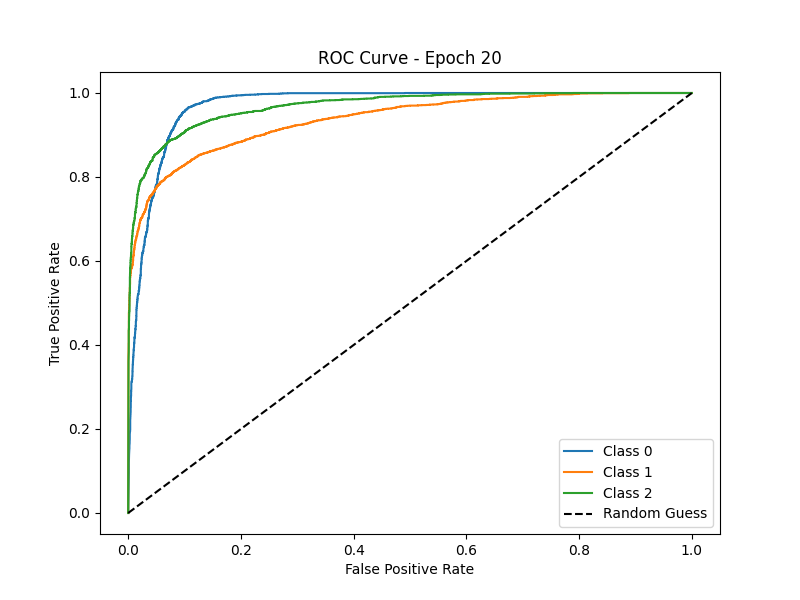

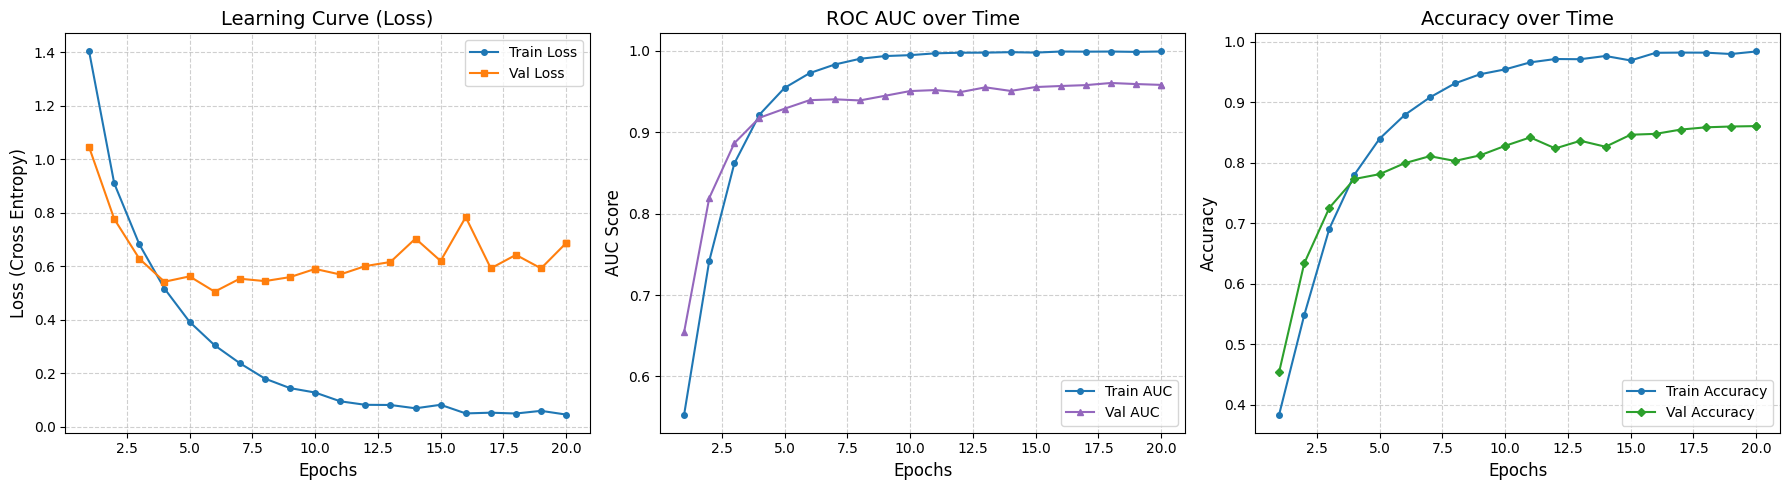

In [4]:
print(f"Fetching Final Results from MLflow Run: {BEST_RUN_ID}\n")


def fetch_metric(metric_name):
    try:
        history = client.get_metric_history(BEST_RUN_ID, metric_name)
        return [m.step for m in history], [m.value for m in history]
    except Exception:
        return [], []


# Fetch metrics
epochs_tl, train_loss = fetch_metric("avg_loss")
epochs_vl, val_loss = fetch_metric("val_avg_loss")

epochs_ta, train_auc = fetch_metric("roc_auc")
epochs_va, val_auc = fetch_metric("val_roc_auc")

epochs_tacc, train_acc = fetch_metric("accuracy")
epochs_vacc, val_acc = fetch_metric("val_accuracy")

final_auc = val_auc[-1] if val_auc else "N/A"
final_acc = val_acc[-1] if val_acc else "N/A"

print(f"Final Validation ROC AUC: {final_auc:.4f}")
if final_acc != "N/A":
    print(f"Final Validation Accuracy: {final_acc:.4f}\n")

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        artifact_path = "validation_metrics/roc_curve_epoch_20.png"
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load the final ROC curve artifact: {e}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
if train_loss and val_loss:
    axes[0].plot(
        epochs_tl,
        train_loss,
        label="Train Loss",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[0].plot(
        epochs_vl,
        val_loss,
        label="Val Loss",
        color="tab:orange",
        marker="s",
        markersize=4,
    )
    axes[0].set_title("Learning Curve (Loss)", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: ROC AUC
if train_auc and val_auc:
    axes[1].plot(
        epochs_ta,
        train_auc,
        label="Train AUC",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[1].plot(
        epochs_va,
        val_auc,
        label="Val AUC",
        color="tab:purple",
        marker="^",
        markersize=5,
    )
    axes[1].set_title("ROC AUC over Time", fontsize=14)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[1].set_ylabel("AUC Score", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Accuracy
if train_acc and val_acc:
    axes[2].plot(
        epochs_tacc,
        train_acc,
        label="Train Accuracy",
        color="tab:blue",
        marker="o",
        markersize=4,
    )
    axes[2].plot(
        epochs_vacc,
        val_acc,
        label="Val Accuracy",
        color="tab:green",
        marker="D",
        markersize=4,
    )
    axes[2].set_title("Accuracy over Time", fontsize=14)
    axes[2].set_xlabel("Epochs", fontsize=12)
    axes[2].set_ylabel("Accuracy", fontsize=12)
    axes[2].legend(loc="lower right")
    axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
# Initialize Hydra and load the config
with initialize(version_base=None, config_path=f"../configs"):
    # Freeze the exact configuration used for this task via overrides
    cfg = compose(
        config_name="config", 
        overrides=[
            "model=pinn_efficient_net_b2_deeplense_classify",
            "dataset=deeplense_classify",
            "training.epochs=5",
            "sampling.sample_every_n_epochs=1",
            "experiment_name=demo_task7"
        ]
    )

print("Active Configuration Locked For Task 7:")
print(f"Model: {cfg.model.name} ({cfg.model.type})")
print(f"Dataset: {cfg.dataset.name}")
print(f"Epochs: {cfg.training.epochs}")

Active Configuration Locked For Task 7:
Model: pinn_efficient_net_b2 (classifier)
Dataset: deeplense_classify
Epochs: 5


In [6]:
from src.data import get_dataloaders, get_datasets, get_stats as get_stats_fn
from src.data.config import DataConfig
from src.models import get_model
from src.training.trainer import Trainer
from src.metrics import get_metric

# Load Data
data_config = DataConfig(**cfg.dataset)
train_dataset, test_dataset = get_datasets(data_config)
train_loader, test_loader = get_dataloaders(data_config)
get_stats = get_stats_fn(data_config)

# Load Model
model = get_model(cfg)

# Load Metrics
metrics = {}
for metric_cfg in cfg.model.metrics.values():
    metrics[metric_cfg.name] = get_metric(metric_cfg, cfg)

# Setup Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr)

# Initialize Trainer
trainer = Trainer(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    test_dataset=test_dataset,
    optimizer=optimizer,
    get_stats=get_stats,
    config=cfg,
    start_epoch=1,
    metrics=metrics
)

Loading dataset: deeplense_classify
Loading dataset: deeplense_classify
Trainer initialized for mode: CLASSIFIER
EMA enabled with decay rate: 0.9999


Fetching a fixed sample batch from the dataloader...


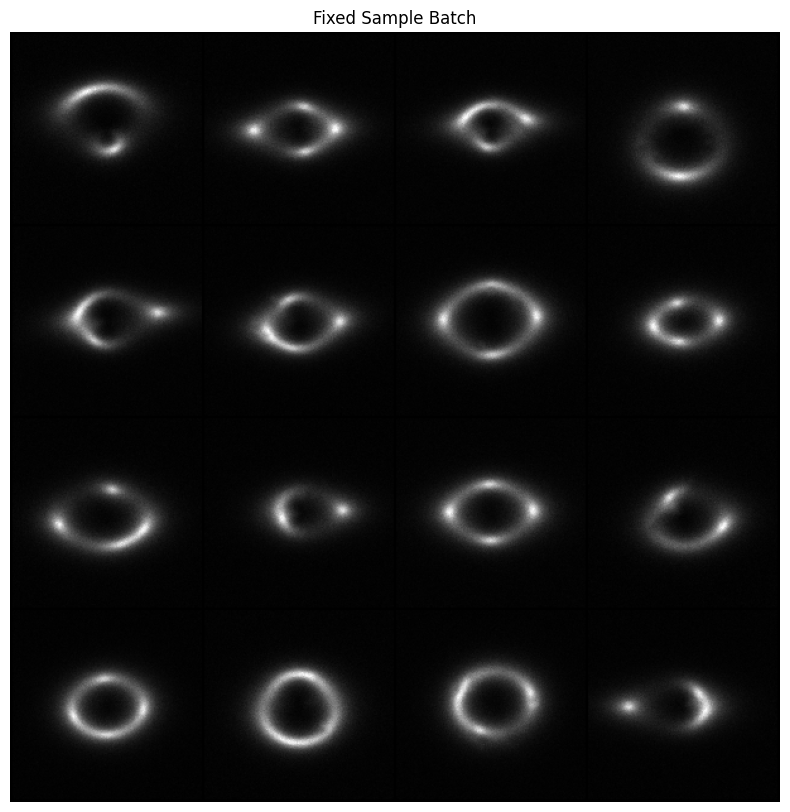

In [7]:
# Visualize what the model is about to see
print("Fetching a fixed sample batch from the dataloader...")
trainer.plot_fixed_batch()

In [8]:
# Start the MLflow run
mlflow.set_experiment(cfg.experiment_name)

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"Started MLflow Run ID: {run_id}")
    
    # Run short 2-epoch demo
    trainer.train()
    
print("Demonstration training complete!")

2026/03/21 17:46:34 INFO mlflow.tracking.fluent: Experiment with name 'demo_task7' does not exist. Creating a new experiment.


Started MLflow Run ID: 01a71deda3e64f40b34f7d43dc082028
Starting training from epoch 1...


Epoch 1: 100%|██████████| 469/469 [02:30<00:00,  3.11it/s, loss=0.975]


Epoch 1 - accuracy: 0.4083
Epoch 1 - roc_auc: 0.5812
Epoch 1 - Average loss: 1.3563


val_1: 100%|██████████| 118/118 [00:09<00:00, 12.86it/s]


...

Validation - Epoch 5 - accuracy: 0.8189
Validation - Epoch 5 - roc_auc: 0.9427
Logged ROC curve for epoch 5 to MLFlow
Average validation loss: 0.4458694047594475
Logged checkpoints for epoch 5 to MLFlow


2026/03/21 18:00:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/21 18:00:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/21 18:00:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Final EMA model saved in MLFlow model format
Logged checkpoints for epoch 5 to MLFlow


val_5: 100%|██████████| 118/118 [00:09<00:00, 12.96it/s]

Validation - Epoch 5 - accuracy: 0.8189
Validation - Epoch 5 - roc_auc: 0.9427
Logged ROC curve for epoch 5 to MLFlow
Average validation loss: 0.4458694047594475
Training complete.
Demonstration training complete!


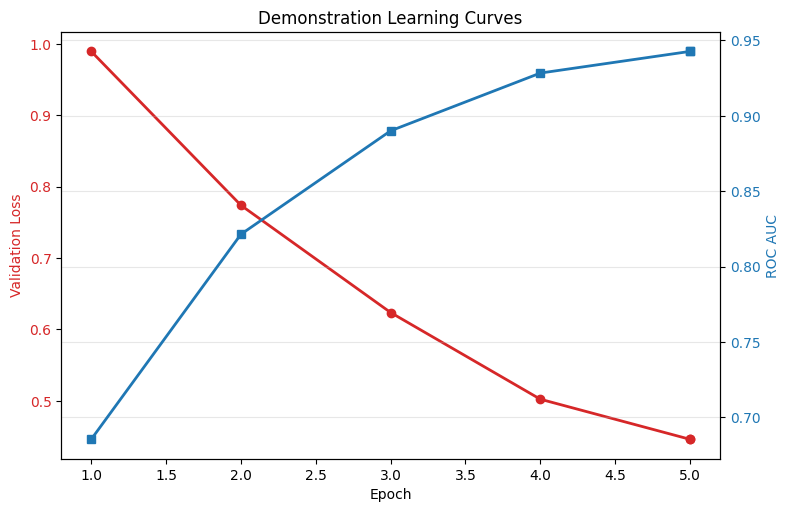

In [9]:
# Fetch the metric history for the run we just completed
client = mlflow.tracking.MlflowClient()

# Extract Validation Loss and ROC AUC
try:
    loss_history = client.get_metric_history(run_id, "val_avg_loss")
    auc_history = client.get_metric_history(run_id, "val_roc_auc")
    
    epochs = [m.step for m in loss_history]
    losses = [m.value for m in loss_history]
    aucs = [m.value for m in auc_history]

    # Plot the learning curves
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss', color=color)
    ax1.plot(epochs, losses, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('ROC AUC', color=color)  
    ax2.plot(epochs, aucs, color=color, marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  
    plt.title("Demonstration Learning Curves")
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f"Could not fetch metric history: {e}")

Latest ROC Curve from MLflow Artifacts:


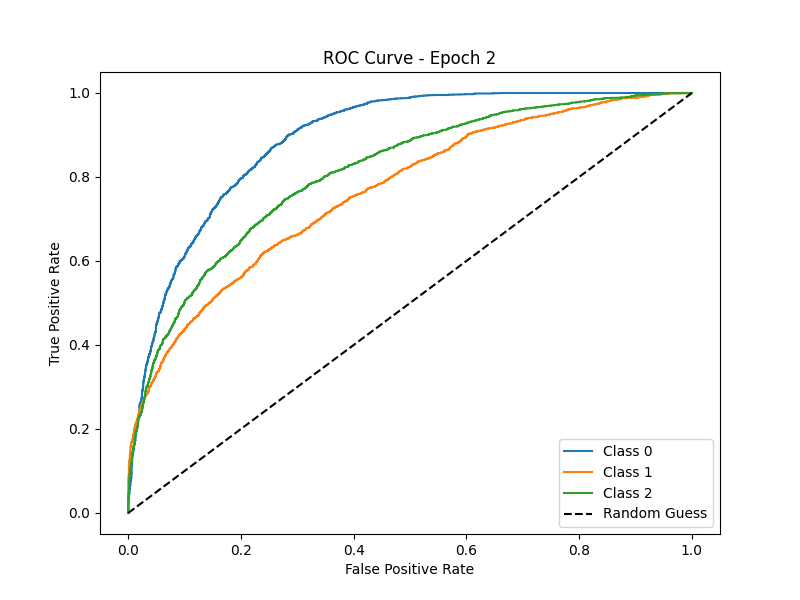

In [10]:
# Download the ROC curve image generated by the trainer and display it directly
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    # Download the specific artifact
    artifact_path = "validation_metrics/roc_curve_epoch_2.png"
    local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
    
    print("Latest ROC Curve from MLflow Artifacts:")
    display(Image(filename=local_path))